# **Logistic Regression** (Sesi 7-8, 2 Maret 2026)

Fadhlan Nur Rachman (2802491960)

Data Dictionary :
- survival:	Survival	0 = No, 1 = Yes
- pclass:	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
- sex:	Sex
- Age:	Age in years
- sibsp	# of siblings / spouses aboard the Titanic
- parch	# of parents / children aboard the Titanic
- ticket:	Ticket number
- fare:	Passenger fare
- cabin:	Cabin number
- embarked:	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [1]:
# Import Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('titanic/train.csv')

In [2]:
train_data.shape

(891, 12)

**Interpretasi cell diatas**:  
terdapat data train sebanyak (891 baris dan 12 fitur) termasuk dengan 1 fitur target


In [3]:
# Preview Dataset
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Drop Unnecessary Columns
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

train_data = train_data.drop(columns=cols_to_drop)
train_data.shape

(891, 8)

**Interpretasi cell diatas**:  
PassengerId, Name, Ticket, dan Cabin dihapus karena variable ini bertipe string dengan unique value yang tinggi atau memiliki banyak data hilang, sehingga data tersebut tidak bisa memberikan pola statistik

# Exploratory Data Analysis

In [5]:
# Check head
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Interpretasi cell diatas**:  
Hasil data train setelah menghapus variable PassengerId, Name, Ticket, dan Cabin


In [6]:
# Identifying Data Structure

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


**Interpretasi cell diatas**:  
cek informasi dari data train terdapat info tipedata dari setiap variable ada 2 float, 4 integer, dan 2 object atau kategorikal data. serta terdapat banyaknya baris yang memiliki isi dari setiap variable nya. dan disini kita bisa mengetahui data lengkap seluruhnya terisi ada 891 dan jika ada variable yang tidak 891 berarti ada missing value


In [7]:
# Summary Statistics for Numerical Columns

train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretasi cell diatas**:  
terdapat hasil statistik data numerical yang bisa menunjukkan distribusi serta kesimpulan dari setiap data nya dan bisa jadi insight untuk kita seperti contoh "rata-rata umur penumpang adalah sekitar 29.7 tahun" lalu ada "tarif(Fare) memiliki standar deviasi yang sangat tinggi 49.69 yang menunjukan adanya kesenjangan harga tiket yang lebar" dan berbagai informasi menarik lainnya


In [8]:
# Summary Statistics for Categorical Columns

train_data.describe(include=['O'])

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Interpretasi cell diatas**:  
terdapat hasil statistik data kategorikal yang menunjukan distribusi jumlah penumpang berdasarkan jenis kelamin(Sex) dan pelabuhan keberangkatan(Embarked). dan ada juga mayoritas seperti penumpang banyak yang naik dari pelabuhan 'S' (Southampton) dan jenis kelamin terbanyak jatuh kepada lelaki dengan frekuensi muncul sebanyak 577

In [9]:
# Percentage of Missing Values

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.00
Pclass,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Fare,0,0.00
Embarked,2,0.22


**Interpretasi cell diatas**:  
Melihat sebuah missing value yang lebih lengkap dimana ternyata terdapat sebuah persentase yang menunjukan 19.86% data umur(Age) ada baris yang hilang serta 0.22% pelabuhan keberangkatan(Embarked) ada baris yang hilang juga

In [10]:
# Cross Tabulation

sex_embarked_ct = pd.crosstab(train_data['Sex'], train_data['Embarked'], dropna=False)

sex_embarked_ct

Embarked,C,Q,S,NaN
Sex,,,,
female,73,36,203,2
male,95,41,441,0


**Interpretasi cell diatas**:  
Menunjukkan distribusi jumlah penumpang berdasarkan jenis kelamin dan pelabuhan keberangkatan. Mayoritas penumpang naik dari pelabuhan 'S' (Southampton) dan sebagai contoh informasi "di pelabuhan southampton terdapat 203 penumpang perempuan yang naik ke kapal"

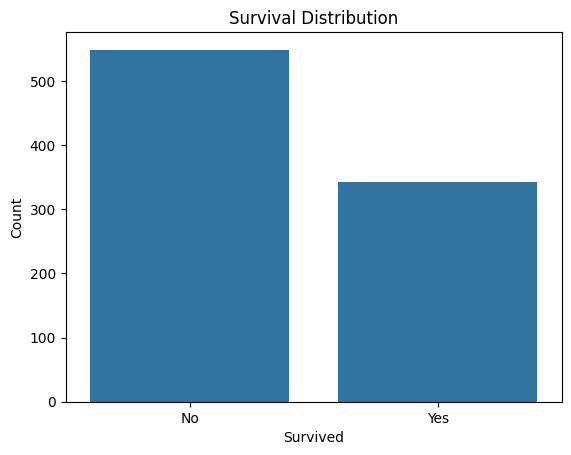

In [11]:
# Bar Plot Survival Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=train_data)
plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

**Interpretasi cell diatas**:  
Terlihat Data target tidak seimbang. jumlah penumpang yang tidak selamat(survived = 0) jauh lebih banyak daripada yang selamat(survived = 1)

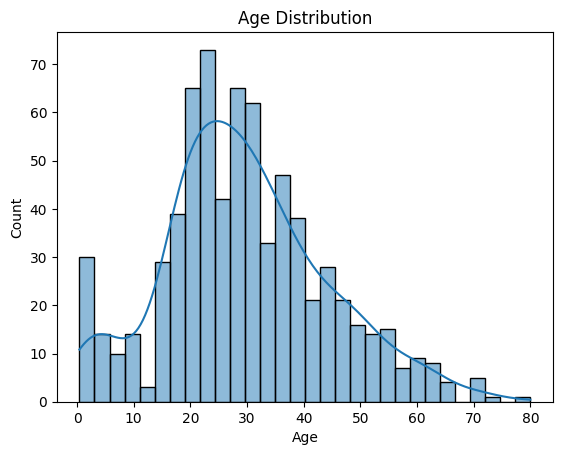

In [12]:
# Age Distribution

sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

**Interpretasi cell diatas**:  
Distribusi histogram umur mendekati kurva normal namus sedikit miring ke kanan(right-skewed), dengan konsentrasi penumpang terbesar berada diusia produktif(20-40 tahun).

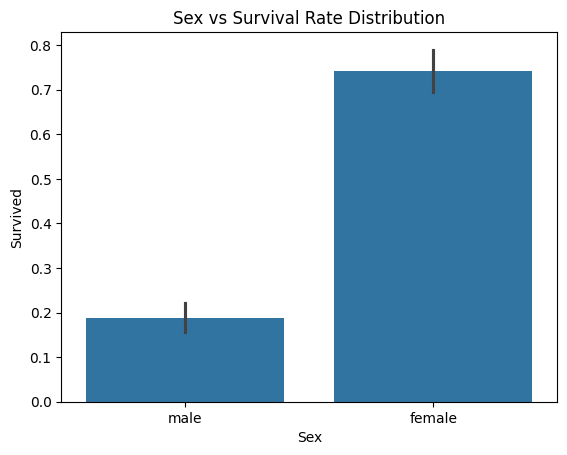

In [13]:
# Sex vs Survival Rate Distribution
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Sex vs Survival Rate Distribution')
plt.show()

**Interpretasi cell diatas**:  
Terdapat perbedaan drastis pada tingkat keselamatan. Perempuan memiliki peluang selamat yang jauh lebih tinggi dibandingkan laki-laki. Ini membuktikan juga aturan wanita didahulukan saat evakuasi.

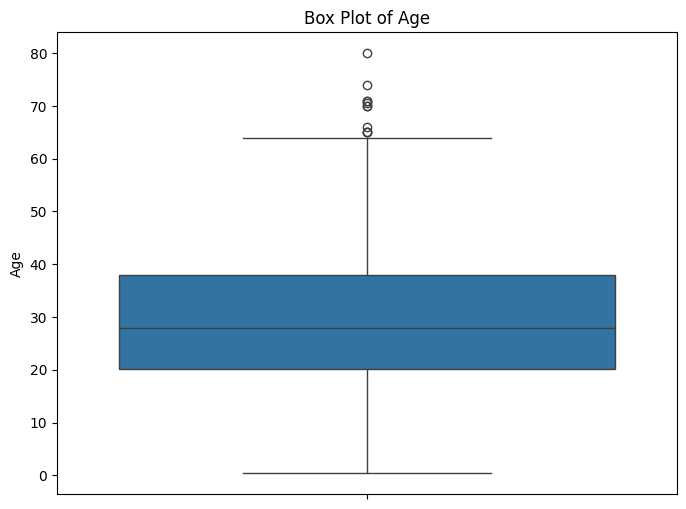

In [14]:
# Box Plot Age

plt.figure(figsize=(8, 6))
sns.boxplot(y=train_data['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

**Interpretasi cell diatas**:  
Terdapat beberapa outlier pada fitur umur (age) menunjukan bahwa ada beberapa data unik yaitu ada lansia dengan umur diatas 65 tahun yang menaiki kapal titanic ini

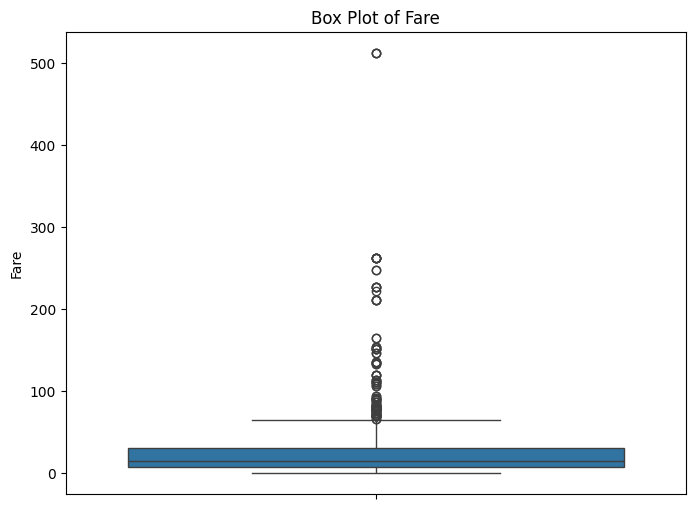

In [15]:
# Box Plot Fare

plt.figure(figsize=(8, 6))
sns.boxplot(y=train_data['Fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')
plt.show()

**Interpretasi cell diatas**:  
Terdapat beberapa outlier pada fitur tarif(fare) dimana kebanyakan orang mempunyai tarif tiket direntang harga 0 hingga 80, dan ada beberapa orang yang membeli tarif tiket diatas harga 80

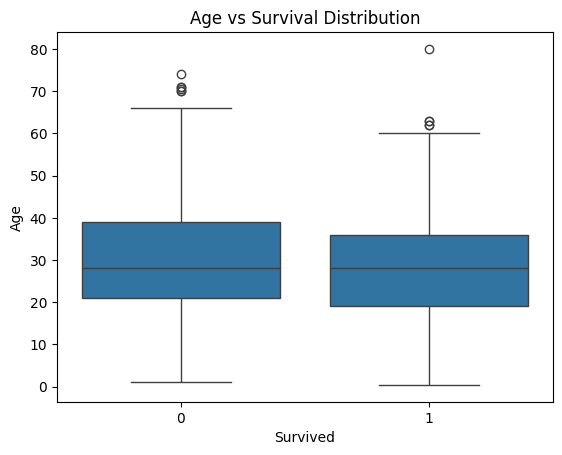

In [16]:
# age vs survived distribution
sns.boxplot(x='Survived', y='Age', data=train_data)
plt.title('Age vs Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.show()

#### Interpretasi cell diatas :
Rentang umur pada kedua kelompok (selamat/tidak selamat) serupa. Namun, pada kelompok selamat, terdapat variasi umur yang lebih lebar di bagian bawah (anak-anak), menunjukkan prioritas keselamatan pada usia muda. lalu kita bisa lihat juga di boxplot terdapat beberapa outlier yang keluar

In [17]:
# Correlation-Based Feature Selection

import numpy as np
numerical_cols = train_data.select_dtypes(include=[np.number]).columns
corr = train_data[numerical_cols].corr()
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Interpretasi cell diatas**:  
Melihat beberapa corelasi antar fitur menggunakan tabel dan cukup sulit dibaca

In [18]:
# Creating an Interactive Heatmap

import plotly.express as px
fig = px.imshow(corr, text_auto='.2f', aspect='auto', color_continuous_scale='RdBu_r', title='Interactive Correlation Matrix')

fig.update_layout(width=800, height=700)
fig.show()

**Interpretasi cell diatas**:  
Melihat beberapa korelasi antar fitur menggunakan heatmap dimana kita bisa melihat dengan jelas secara detail juga korelasi antar fiturnya seperti tarif(fare) dan kelas penumpang(pclass) memiliki korelasi tinggi bertolak belakang atau minus

In [19]:
# Top Correlated Features with 'Survived'

top_corr = corr['Survived'].abs().sort_values(ascending=False).head(6)
top_corr

Survived    1.000000
Pclass      0.338481
Fare        0.257307
Parch       0.081629
Age         0.077221
SibSp       0.035322
Name: Survived, dtype: float64

**Interpretasi cell diatas**:<br>
Top fitur secara ascending yang berkorelasi dengan fitur target(Survived)

# Data Preprocessing

In [20]:
# Drop Column with 50% Missing Values

missing_ratio = train_data.isnull().mean()
cols_to_keep = missing_ratio[missing_ratio <= 0.5].index
train_data = train_data[cols_to_keep]
train_data.shape

(891, 8)

**Interpretasi cell diatas**:<br>
Menghapus fitur/kolom yang mempunyai missing value diatas 50%, namun karena di dataset ini yang mempunyai missing value terbanyak hanya 19.87% jadi tidak ada yang terkena drop missing value code ini

In [21]:
# Age Imputation with Mean

train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

**Interpretasi cell diatas**:<br>
Mengisi missing value variable umur(Age) menggunakan rata-rata(Mean) karena umur adalah data numerik yang distribusi nya cukup padat

In [22]:
# Embarked with Mode

train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

**Interpretasi cell diatas**:<br>
Mengisi missing value variable Pelabuhan Keberangkatan(Embarked) karena hanya 2 data hilang ktia menggunakan modus karena umur adalah data kategorikal, maka diisi dengan nilai yang paling sering muncul.

In [23]:
# Re check Missing Values

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.0
Pclass,0,0.0
Sex,0,0.0
Age,0,0.0
SibSp,0,0.0
Parch,0,0.0
Fare,0,0.0
Embarked,0,0.0


**Interpretasi cell diatas**:<br>
Setelah proses mengisi missing value bisa dilihat sekarang sudah tidak ada lagi data yang hilang atau tidak terisi

In [24]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in ['Sex', 'Embarked']:
    train_data[col] = le.fit_transform(train_data[col])

**Interpretasi cell diatas**:<br>
Mengubah data kategorikal menjadi angka agar bisa dibaca algoritma dan komputer, dimana contoh: (Male/Female) menjadi 0 dan 1

In [25]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


**Interpretasi cell diatas**:<br>
Konfirmasi data kategorikal sudah berubah menjadi numerical yang sudah bisa dibaca oleh komputer

In [26]:
# Seperate Target Class

x = train_data.drop('Survived', axis=1)
y = train_data['Survived']

**Interpretasi cell diatas**:<br>
Memisahkan fitur dependen(y) dan independen(x) lalu mendeklarasikannya di variable baru

In [27]:
# Split dataset into training and testing 70:30

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

**Interpretasi cell diatas**:  
Membagi data Training (Data latih) dan data Validation (Data Validasi) dengan rasio 70:30 dan diacak secara konsisten dan juga mengelompokan sesuai bobot kelasnya agar tidak imbalance class

In [28]:
# Normalization with Standard Scaler

from sklearn.preprocessing import StandardScaler

scale_cols = ['Age', 'Fare']

scaler = StandardScaler()

x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

**Interpretasi cell diatas**: 
transformasi atau standarisasi kolom umur(age) dan tarif(fare) memiliki skala yang sangat tinggi dengan data yang lainnya dan standarisasi mengubah data sehingga memiliki rata-rata = 0 dan standar deviasi = 1, lalu standar scaler(z-score) ini memiliki rentang dari -1 hingga 1

In [29]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
748,1,1,-0.842505,1,0,0.465738,2
45,3,1,-0.021501,0,0,-0.478269,2
28,3,0,-0.021501,0,0,-0.481848,1
633,1,1,-0.021501,0,0,-0.646954,2
403,3,1,-0.151884,1,0,-0.314823,2


**Interpretasi cell diatas**: 
hasil transformasi atau standarisasi variable umur(age) dan tarif(fare) supaya rentang nya sama

In [30]:
# Train Logistic Regression Model dengan class_weight='balanced'
from sklearn.linear_model import LogisticRegression

modelLR = LogisticRegression(class_weight='balanced')
modelLR.fit(x_train, y_train)

# Train Naive Bayes Model
from sklearn.naive_bayes import GaussianNB

modelNB = GaussianNB()
modelNB.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


**Interpretasi cell diatas**: 
Memanggil model logistic regression dan melatih nya menggunakan weight balancing untuk menangani imbalance fitur target

In [31]:
# Predict the Testing Data model Logistic Regression vs Naive Bayes

y_pred = modelLR.predict(x_test)
y_prob = modelLR.predict_proba(x_test)[:, 1]
y_pred_nb = modelNB.predict(x_test)
y_prob_nb = modelNB.predict_proba(x_test)[:, 1]

**Interpretasi cell diatas**: 
Model yang telah dilatih lalu diprediksi dengan datatest untuk mencoba mengevaluasi model yang sudah dibuat nantinya

In [32]:
y_pred
y_pred_nb

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1])

**Interpretasi cell diatas**: 
hasil keseluruhan prediksi Survived dalam bentuk array dengan bentuk biner 0 = No/Death, 1 = Yes/Death

# Model Evaluation

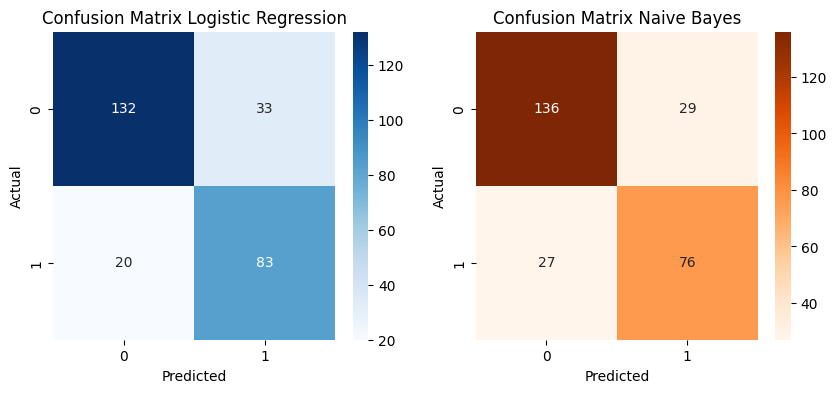

In [37]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1, 2, 2)
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Interpretasi cell diatas**: <br>
Dari confusion matrix dapat dilihat bahwa model memprediksi:
- **True Negative (TN) = 132**: penumpang yang tidak selamat dan diprediksi tidak selamat (benar)
- **False Positive (FP) = 33**: penumpang yang tidak selamat tetapi diprediksi selamat (salah)
- **False Negative (FN) = 20**: penumpang yang selamat tetapi diprediksi tidak selamat (salah)
- **True Positive (TP) = 83**: penumpang yang selamat dan diprediksi selamat (benar)

Total prediksi benar adalah 132 + 83 = 215 dari 268 data testing. Model lebih sering salah memprediksi penumpang tidak selamat sebagai selamat (FP=33) dibanding sebaliknya (FN=20), yang menunjukkan weight balancing berhasil meningkatkan sensitivitas model terhadap kelas minoritas (Survived=1)

In [34]:
# Metrics Evaluation

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"F1 Macro       : {f1_macro:.4f}")
print(f"F1 Weighted    : {f1_weighted:.4f}")
print("\n--- Classification Report ---\n")

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Not Survived', 'Survived']))

Accuracy       : 0.8022
Precision      : 0.7155
Recall         : 0.8058
F1 Score       : 0.7580
F1 Macro       : 0.7954
F1 Weighted    : 0.8041

--- Classification Report ---

Logistic Regression Classification Report:
              precision    recall  f1-score   support

Not Survived       0.87      0.80      0.83       165
    Survived       0.72      0.81      0.76       103

    accuracy                           0.80       268
   macro avg       0.79      0.80      0.80       268
weighted avg       0.81      0.80      0.80       268

Naive Bayes Classification Report:
              precision    recall  f1-score   support

Not Survived       0.83      0.82      0.83       165
    Survived       0.72      0.74      0.73       103

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



**Interpretasi cell diatas**: <br>
Berikut penjelasan dari setiap metrik evaluasi:
- **Accuracy (0.8022)**: Dari seluruh data testing, 80.22% diprediksi dengan benar. Artinya model cukup baik secara keseluruhan
- **Precision (0.7155)**: Dari semua yang diprediksi selamat, 71.55% benar-benar selamat. Sisanya adalah false positive
- **Recall (0.8058)**: Dari semua penumpang yang sebenarnya selamat, model berhasil mendeteksi 80.58%. Recall yang tinggi menunjukkan weight balancing efektif membuat model lebih sensitif terhadap kelas minoritas
- **F1 Score (0.7580)**: Rata-rata harmonis dari precision dan recall untuk kelas positif (Survived=1), menunjukkan keseimbangan yang baik antara keduanya
- **F1 Macro**: Rata-rata F1 dari kedua kelas tanpa mempertimbangkan jumlah sampel per kelas, berguna untuk melihat performa model secara adil di kedua kelas
- **F1 Weighted**: Rata-rata F1 yang mempertimbangkan proporsi jumlah sampel per kelas, sehingga kelas mayoritas memiliki bobot lebih besar

Classification Report memberikan ringkasan lengkap precision, recall, dan f1-score untuk setiap kelas beserta support (jumlah data aktual per kelas)

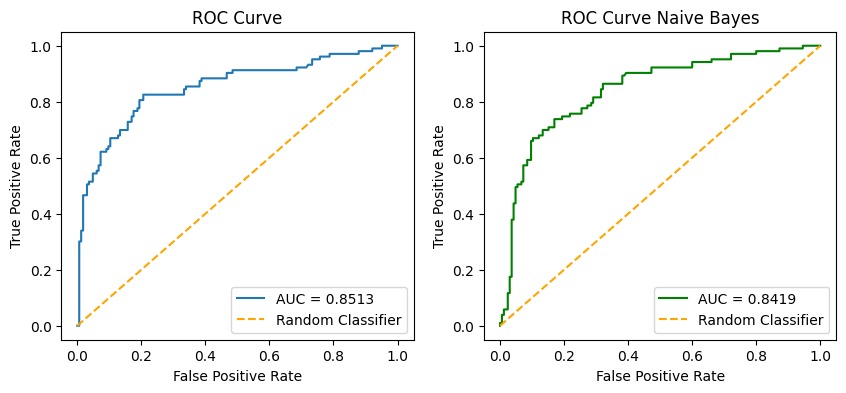

AUC Score: 0.8513
AUC Score Naive Bayes: 0.8419


In [38]:
# Create ROC Curve and AUC

from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='orange', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(fpr_nb, tpr_nb, label=f'AUC = {auc_nb:.4f}', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='orange', label='Random Classifier')
plt.title('ROC Curve Naive Bayes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {auc:.4f}")
print(f"AUC Score Naive Bayes: {auc_nb:.4f}")

**Interpretasi cell diatas**: <br>
ROC Curve menggambarkan hubungan antara True Positive Rate (Recall) dan False Positive Rate pada berbagai threshold klasifikasi.
- **AUC (Area Under Curve) = 0.8513**: Nilai AUC sebesar 0.85 menunjukkan bahwa model memiliki kemampuan diskriminasi yang baik dalam membedakan antara penumpang yang selamat dan tidak selamat
- Kurva ROC yang berada jauh di atas garis diagonal menunjukkan bahwa model jauh lebih baik daripada random classifier (tebakan acak yang AUC-nya 0.5)
- Semakin mendekati pojok kiri atas (FPR=0, TPR=1), semakin baik performa model. Kurva model ini mendekati area tersebut yang berarti model cukup baik
- Secara umum, AUC di atas 0.8 dikategorikan sebagai model dengan performa yang baik